# Assignment 4

## Imports

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import tqdm.notebook
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Task 1 — Build an MLP using `torch.nn.Module` and `nn.Sequential` (1 pts)

Build a classifier for CIFAR-10 using the architecture:

$$
3072 \rightarrow 512 \rightarrow 256 \rightarrow 10
$$

with ReLU activations.

### Requirements


1. Load **CIFAR-10**
2. Split the training set into **train / validation**
3. Flatten each image into a vector of size 3072
4. Implement the model in **two ways**:
   * using `nn.Sequential`
   * using a custom class inheriting from `nn.Module`
5. Print the model
6. Count the number of trainable parameters

In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [7]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)


In [14]:
model_seq = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
model_mod = MLP()

In [15]:
print(model_seq)
print(model_mod)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=10, bias=True)
)
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


Trainable parameters: (3072 * 512) + (1 * 512) + (512 * 256) + (1 * 256) + (256 * 10) + (1 * 10) = 1707274

In [17]:
(3072 * 512) + (1 * 512) + (512 * 256) + (1 * 256) + (256 * 10) + (1 * 10)

1707274

- `torch.nn.Module` is the base class for neural network components in PyTorch. It provides the model interface (`forward`), mode switching (`train`/`eval`), device transfer (`to`), state saving/loading (`state_dict`), and parameter iteration (`parameters`).

- PyTorch automatically tracks parameters because when you assign layers (like `nn.Linear`) as attributes of a module, their weights/biases are stored as `nn.Parameter` objects and registered internally. Registration is recursive, so submodules inside other submodules are tracked too.

- `nn.Sequential` is convenient when the model is a simple chain of layers with one input and one output flow (e.g., Flatten -> Linear -> ReLU -> Linear ...). It is concise and readable.

- A custom `nn.Module` is preferable when you need non-linear control flow, multiple inputs/outputs, skip/residual connections, shared layers, conditional branches, or extra logic in `forward`.


### Required explanation

Explain:

* what `torch.nn.Module` represents,
* why PyTorch automatically tracks parameters inside a module,
* when `nn.Sequential` is convenient,
* when a custom `nn.Module` is preferable.

---

* `torch.nn.Module` is base class for all neural network models. You get all the blueprint methods and need to fill only `__init__` and `forward(self, x)`
* Parameters are tracked because they are `nn.Parameters` objects so that we can use inbuilt functions properly.
* `nn.Sequential` is fine for simple models. It allows quick model building without a lot of template code.
* `nn.Module` is wanted when dealing with larger models. It allows for more customization.

## Task 2 — Standard Training Loop with Mini-Batches (2 pts)

Implement a standard PyTorch training loop.

### Requirements


1. Use `DataLoader` with mini-batches
2. Use:
   * `CrossEntropyLoss`
   * plain **SGD**
3. Train for at least **10 epochs**
4. Track:
   * training loss,
   * validation loss,
   * training accuracy,
   * validation accuracy
5. Plot:
   * loss vs epoch,
   * accuracy vs epoch

### Required code elements

Your code should clearly show:

* `model.train()`
* `model.eval()`
* forward pass
* loss computation
* `optimizer.zero_grad()`
* `loss.backward()`
* `optimizer.step()`
* validation under `torch.no_grad()`

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [9]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [25]:
model = MLP().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [51]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=100):
    loss_train = []
    acc_train = []
    loss_val = []
    acc_val = []


    for epoch in tqdm.notebook.trange(epochs):
        loss, acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        loss_train.append(loss)
        acc_train.append(acc)

        loss, acc = evaluate(model, val_loader, criterion, device)
        loss_val.append(loss)
        acc_val.append(acc)
    return loss_train, loss_val, acc_train, acc_val

In [ ]:
loss_train, loss_val, acc_train, acc_val = train_model(model, train_loader, val_loader, optimizer, criterion, device)

In [58]:
def plot_loss_acc(loss_train, loss_val, acc_train, acc_val, title=''):

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].plot(loss_train, label='Train')
    axes[0].plot(loss_val, label='Validation')
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(acc_train, label="Train")
    axes[1].plot(acc_val, label='Validation')
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    if title:
        fig.suptitle(title, fontsize=14)

    plt.show()

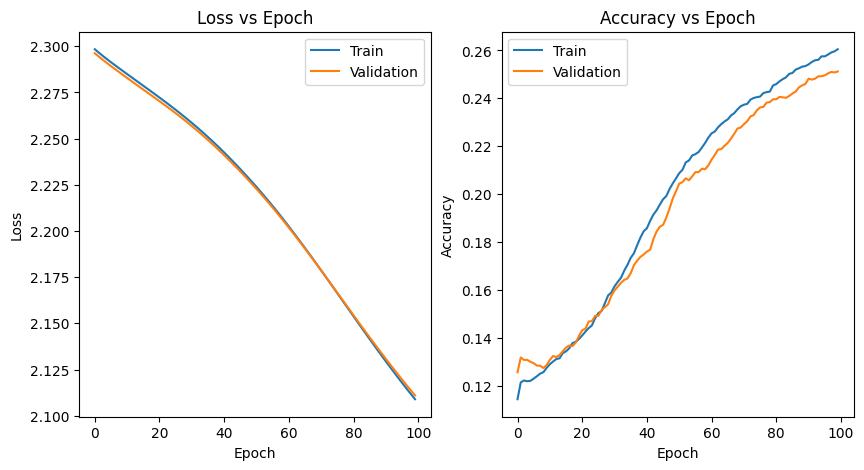

In [59]:
plot_loss_acc(loss_train, loss_val, acc_train, acc_val)

### Required explanation

Explain:

* why we use mini-batches,
* what `model.train()` and `model.eval()` do,
* why gradients are disabled during validation,
* why `optimizer.zero_grad()` is necessary.

---

* Mini-batches are used, because whole batch can be to large for memory to fit.
* `model.train()` enables training features (dropout, batch norm)
* `model.eval()` disables training features (dropout, batch norm)
* Calculating gradients takes extra time and there is no need for them in validation because we aren't training model on this data.
* If it was not implemented then gradients would accumulate through batches and epochs.

## Task 3 — Optimizer Comparison (4 pts)

Compare the following optimizers:

* SGD
* SGD + Momentum
* SGD + Nesterov
* RMSprop
* Adam

Use the **same dataset**, **same model architecture**, **same batch size**, and **same number of epochs**.
Change only the optimizer.

It is allowed to use optimizers from `torch.optim` ; see @[https://docs.pytorch.org/docs/stable/optim.html](mention://26f43b9b-dea4-48e5-824c-64ac95049baa/url/a8e139ae-c53c-4ce7-b62d-ba468bf4b310)

### Requirements

For each optimizer:


1. Train the same MLP
2. Plot training and validation loss
3. Plot training and validation accuracy
4. Report final validation accuracy
5. Compare convergence speed

### Suggested hyperparameters

You may start from:

* SGD: `lr=0.1`
* SGD + Momentum: `lr=0.1, momentum=0.9`
* SGD + Nesterov: `lr=0.1, momentum=0.9, nesterov=True`
* RMSprop: `lr=0.001`
* Adam: `lr=0.001`

You may tune them slightly if needed, but all final choices must be reported.

### Required summary table

Create a final table with:

* optimizer name
* learning rate
* final train loss
* final validation loss
* final train accuracy
* final validation accuracy

In [53]:
optimizer_configs = [
    {"name": "SGD", "cls": optim.SGD, "kwargs": {"lr": 0.1}},
    {"name": "SGD+Momentum", "cls": optim.SGD, "kwargs": {"lr": 0.1, "momentum": 0.9}},
    {"name": "SGD+Nesterov", "cls": optim.SGD, "kwargs": {"lr": 0.1, "momentum": 0.9, "nesterov": True}},
    {"name": "RMSprop", "cls": optim.RMSprop, "kwargs": {"lr": 0.001}},
    {"name": "Adam", "cls": optim.Adam, "kwargs": {"lr": 0.001}},
]

  0%|          | 0/50 [00:00<?, ?it/s]

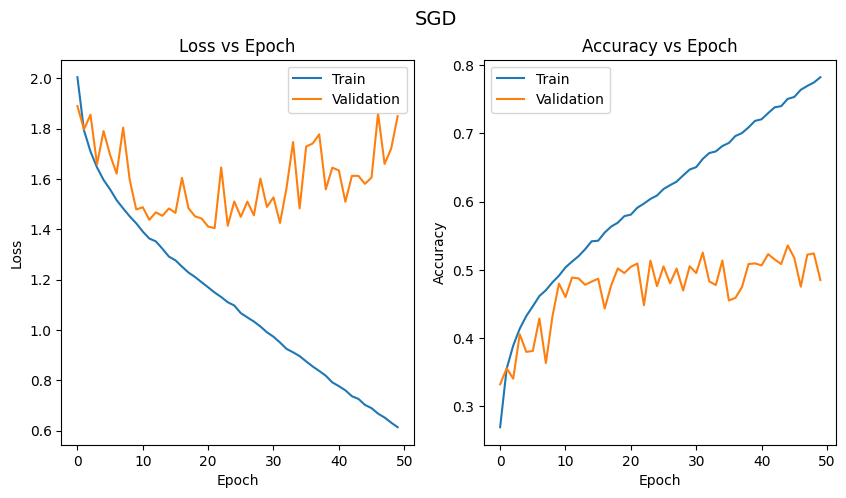

  0%|          | 0/50 [00:00<?, ?it/s]

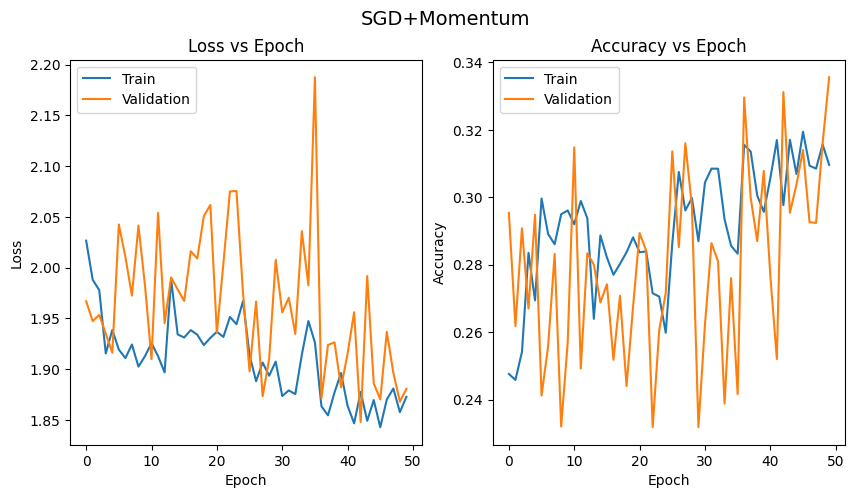

  0%|          | 0/50 [00:00<?, ?it/s]

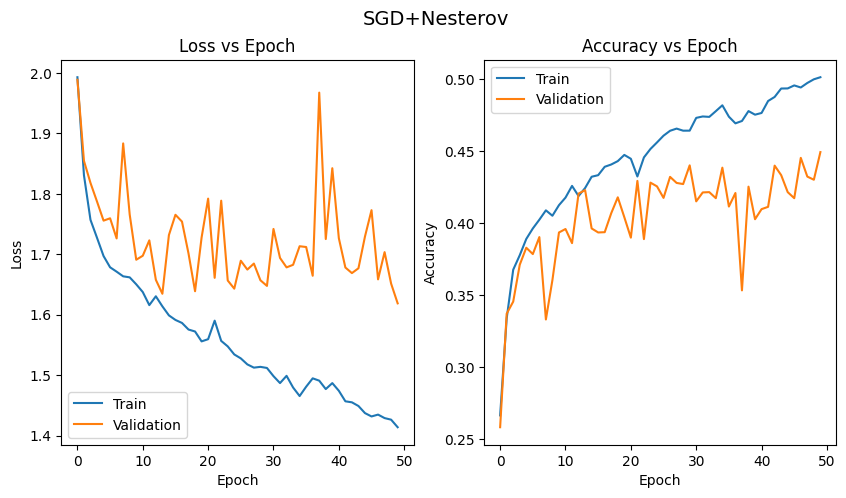

  0%|          | 0/50 [00:00<?, ?it/s]

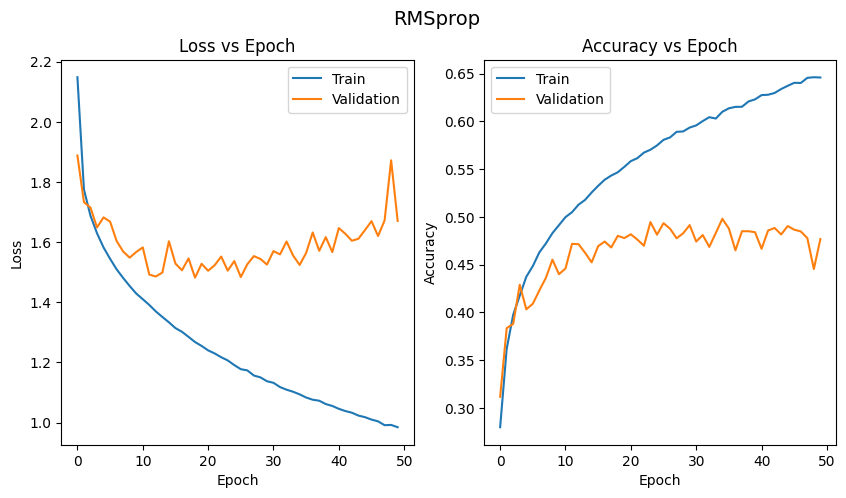

  0%|          | 0/50 [00:00<?, ?it/s]

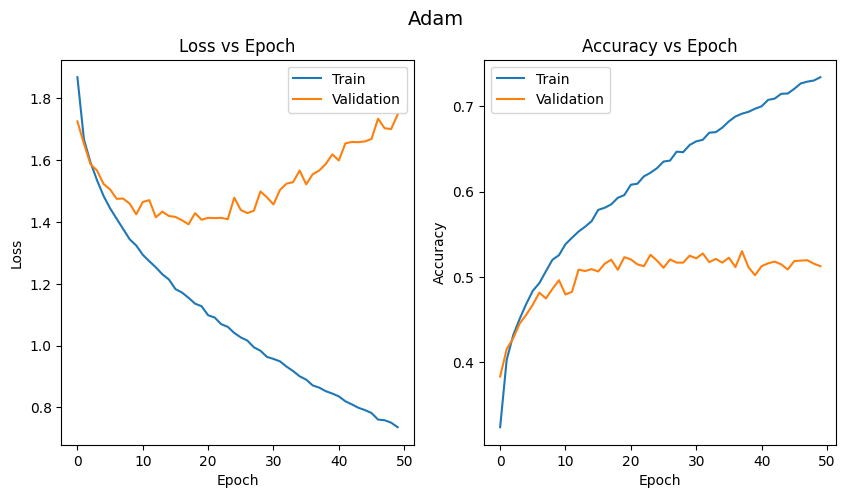

In [60]:
rows = []

for config in optimizer_configs:
    model = MLP().to(device)
    optimizer = config['cls'](model.parameters(), **config['kwargs'])
    criterion = nn.CrossEntropyLoss()
    loss_train, loss_val, acc_train, acc_val = train_model(model, train_loader, val_loader, optimizer, criterion, device, 50)

    plot_loss_acc(loss_train, loss_val, acc_train, acc_val, config['name'])

    rows.append({
        "optimizer": config["name"],
        "lr": config["kwargs"]["lr"],
        "final_train_loss": loss_train[-1],
        "final_val_loss": loss_val[-1],
        "final_train_acc": acc_train[-1],
        "final_val_acc": acc_val[-1],
    })

In [61]:
results_df = pd.DataFrame(rows).sort_values("final_val_acc", ascending=False)
results_df

,optimizer,lr,final_train_loss,final_val_loss,final_train_acc,final_val_acc
4,Adam,0.001,0.736048,1.748262,0.733978,0.5124
0,SGD,0.100,0.613876,1.849792,0.782489,0.4850
3,RMSprop,0.001,0.984479,1.670362,0.646000,0.4768
2,SGD+Nesterov,0.100,1.414002,1.618784,0.501378,0.4494
1,SGD+Momentum,0.100,1.872921,1.880795,0.309600,0.3356


### Required explanation

Discuss:

* which optimizer converged fastest,
* which optimizer achieved the best validation result,
* whether adaptive methods behaved differently from SGD,
* whether Momentum / Nesterov improved over plain SGD.

---

* Adam converged the fastest.
* Adam achieved the best final validation accuracy.
* Adaptive optimizers (Adam/RMSprop) improved much faster early, while plain SGD learned more slowly and needed more tuning.
* Both Momentum and Nesterov improved over SGD.

## Task 4 — Weight Initialization (3 pts)

Study how initialization affects activations, gradients, and training stability.

Compare:

* default random or initialization (e.g. N(0,1)) → experiment with small and big variance, too;
* Xavier initialization
* He initialization

Use a deeper MLP with **3 to 6 hidden layers**.


---

### Part A — Statistical forward/backward experiment

Before training, you may use a batch of **random input noise** as an additional diagnostic experiment.

A good choice is input sampled from a normalized distribution:

$$
x \sim \mathcal{N}(0, 1)
$$

This is useful because it removes dataset-specific structure and lets you focus only on the effect of initialization.
If the input has mean close to 0 and variance close to 1, then changes in activation and gradient statistics across layers are easier to interpret.

You may therefore do **one or both** of the following:


1. use one real mini-batch from CIFAR-10,
2. use random normalized input noise with mean 0 and variance 1.


---

### Experiment

Without full training, pass one mini-batch through the network and measure for each layer:

* mean of activations,
* variance of activations.

Then perform one backward pass and measure:

* mean of gradients,
* variance of gradients.

Present results in a table or plot.


---

### Part B — Small training experiment

Train the models for a few epochs and compare:

* training loss,
* validation accuracy,
* gradient norms.


---

### Required explanation

Discuss:

* why initialization matters,
* why He initialization is usually good for ReLU networks,
* when Xavier initialization is more natural,
* whether poor initialization can contribute to vanishing or exploding activations/gradients,
* whether random normalized input noise was useful for isolating the effect of initialization.

You do **not** need to prove the formulas theoretically.
The goal is to observe the behavior experimentally.

In [63]:
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

In [64]:
def init_model(model, scheme="default"):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if scheme == "default":
                pass  # keep PyTorch defaults
            elif scheme == "normal_small":
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.zeros_(m.bias)
            elif scheme == "normal_big":
                nn.init.normal_(m.weight, mean=0.0, std=1.0)
                nn.init.zeros_(m.bias)
            elif scheme == "xavier":
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif scheme == "he":
                nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                nn.init.zeros_(m.bias)
            else:
                raise ValueError(f"Unknown scheme: {scheme}")

In [65]:
schemas = ['default', 'normal_small', 'normal_big', 'xavier', 'he']

X_batch, y_batch = next(iter(train_loader))
X_batch, y_batch = X_batch.to(device), y_batch.to(device)

def analyze_init(model, X_batch, y_batch):
    activations = []
    x = X_batch

    for layer in model.net:
        x = layer(x)
        if isinstance(layer, nn.ReLU):
            activations.append(x.detach().cpu())

    logits = x

    criterion = nn.CrossEntropyLoss()
    loss = criterion(logits, y_batch)

    model.zero_grad()
    loss.backward()

    gradients = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            gradients.append(param.grad.detach().cpu())

    return activations, gradients

stats = []

for schema in schemas:
    model = DeepMLP().to(device)
    init_model(model, schema)

    acts, grads = analyze_init(model, X_batch, y_batch)

    act_means = [a.mean().item() for a in acts]
    act_vars = [a.var().item() for a in acts]
    grad_means = [g.mean().item() for g in grads]
    grad_vars = [g.var().item() for g in grads]

    stats.append({
        "Scheme": schema,
        "Act Mean": np.mean(act_means),
        "Act Var": np.mean(act_vars),
        "Grad Mean": np.mean(grad_means),
        "Grad Var": np.mean(grad_vars)
    })

pd.DataFrame(stats)

,Scheme,Act Mean,Act Var,Grad Mean,Grad Var
0,default,0.058653,1.179845e-02,-1.919931e-06,1.330873e-07
1,normal_small,0.033487,8.014313e-03,-4.769019e-09,8.471585e-12
2,normal_big,3977.790196,1.096462e+08,7.313191e+01,3.569171e+06
3,xavier,0.192724,1.022958e-01,1.357499e-04,1.594363e-05
4,he,0.231811,1.388390e-01,3.336297e-04,8.037724e-05


In [ ]:
# Part B
training_rows = []
for schema in schemas:
    model = DeepMLP().to(device)
    init_model(model, schema)
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    loss_train, loss_val, acc_train, acc_val = train_model(
        model, train_loader, val_loader, optimizer, criterion, device, epochs=3
    )

    plot_loss_acc(loss_train, loss_val, acc_train, acc_val, title=f"Init: {schema}")

    training_rows.append({
        "Scheme": schema,
        "Final Train Loss": loss_train[-1],
        "Final Val Acc": acc_val[-1]
    })

pd.DataFrame(training_rows).sort_values("Final Val Acc", ascending=False)

### Required explanation
Discuss:

* why initialization matters,
* why He initialization is usually good for ReLU networks,
* when Xavier initialization is more natural,
* whether poor initialization can contribute to vanishing or exploding activations/gradients,
* whether random normalized input noise was useful for isolating the effect of initialization.

---

* Initialization matters because if weights are too small, activations and gradients shrink to zero (vanishing gradients), so the network stops learning. If weights are too large, activations and gradients explode, causing NaNs and numerical instability.
* He initialization is mathematically derived to keep the variance of the input the same as the variance of the output specifically for ReLU activation. Since ReLU zeros out half of the pre-activations, He initialization roughly doubles the variance of the weights compared to Xavier initialization to compensate.
* Xavier initialization aims to keep the variance of activations and gradients the same across layers. It achieves this by scaling the weights based on the number of input and output features. It is natural when using symmetric activation functions with a linear regime around 0, like Tanh or Sigmoid.
* Yes, poor initialization directly leads to vanishing (small random weights) or exploding (large random weights) activations and gradients.
* Yes, a batch from N(0,1) removes the actual image distributions, allowing an unbiased look purely at the operations of matrix multiplications and activations across multiple layers.


## Task 5 — (Optional Bonus) Manual Optimizers (+2 pts)

Implement selected optimizers manually for a small model.

See lecture notes —  [Optimizers](/doc/4aa6cfed-056a-417c-92b0-f28d077ce5f5)  — for more math details.


---

### Points

* Momentum: **0.5 pt**
* Nesterov: **0.5 pt**
* RMSprop: **0.5 pt**
* Adam: **0.5 pt**


---

### Suggested formulas

### Momentum

$$
v_t = \beta v_{t-1} - \eta \nabla_\theta L
$$

$$
\theta_t = \theta_{t-1} + v_t
$$


---

### Nesterov

Use a momentum-style update with **look-ahead gradient evaluation**;


---

### RMSprop

Maintain a running average of squared gradients and scale the update:

$$
s_t = \rho s_{t-1} + (1 - \rho)(\nabla_\theta L)^2
$$

$$
\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{s_t + \varepsilon}} \nabla_\theta L
$$


---

### Adam

Combine momentum and adaptive scaling:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)\nabla_\theta L
$$

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla_\theta L)^2
$$

$$
\theta_t = \theta_{t-1} - \eta \frac{m_t}{\sqrt{v_t} + \varepsilon}
$$


---

### Requirements


1. Implement at least one small model
2. Implement each optimizer manually:
   * Momentum
   * Nesterov
   * RMSprop
   * Adam
3. Compare the training curves
4. Compare your implementations with PyTorch optimizers
5. Briefly comment on whether the behavior is similar


---

### Required explanation

Explain:

* the main idea behind each optimizer,
* how Momentum and Nesterov differ,
* how RMSprop adapts the step size,
* how Adam combines momentum and adaptive scaling.


